## **Pairwise-Comparison-OpenSWATH-CV**

Here across libraries look at peptide precursors that are only confidently identified in all 3 of the reconstructed libraries and not found in the intersection of the initial libraries. Can only do this with OpenSWATH because DIA-NN does not output peptide precursors that are not confidently identified.  

In [1]:
import pandas as pd
import polars as pl
from functools import reduce
from itertools import combinations
import seaborn as sns
import matplotlib.pyplot as plt
from collections import defaultdict
import sys
import numpy as np
import matplotlib as mpl


sys.path.append("../../scripts")

from figure_utils import *

In [2]:
print("Pandas Version", pd.__version__)
print("Polars Version", pl.__version__)
print("numpy Version", np.__version__)
print("matplotlib version", mpl.__version__)
print("seaborn version", sns.__version__)
print("Python Version", sys.version)

Pandas Version 2.2.3
Polars Version 1.28.1
numpy Version 2.2.2
matplotlib version 3.10.0
seaborn version 0.13.2
Python Version 3.12.4 (main, Jun  7 2024, 23:47:47) [GCC 13.3.0]


In [3]:
def formatData(rslts):
    rslts_reduced = reduce(lambda x, y: pd.merge(x,y, left_index=True, right_index=True, how='inner'), rslts.values())    
    # only fill na of intensities, other columns leave missing
    #rslts_reduced[ [f'FEATURE_MS2.AREA_INTENSITY_{i}' for i in rslts.keys() ] ] = rslts_reduced[ [f'FEATURE_MS2.AREA_INTENSITY_{i}' for i in rslts.keys() ] ].fillna(0)
                      
    # compute CV across all
    columns = ['FEATURE_MS2.AREA_INTENSITY' + '_' + i for i in rslts.keys() ] 
    
    rslts_reduced['cv'] = rslts_reduced[columns].std(axis=1) / rslts_reduced[columns].mean(axis=1) * 100 
    
    return rslts_reduced

---

---

In [4]:
names = dict(exp='Experimental',
             silico='in-silico',
             bruker='timsTOF, 2024',
             panhuman='PanHuman, 2014')

condition = dict(orig='Initial', refined='Reconstructed')

In [5]:
osw = { n:defaultdict(dict) for n in names.values() }

# Bruker data
osw[names['bruker']][condition['orig']]['1'] = getPrecursorSet("../../results/K562-Bruker-Library-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.parquet")
osw[names['bruker']][condition['orig']]['2'] = getPrecursorSet("../../results/K562-Bruker-Library-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021.parquet")
osw[names['bruker']][condition['orig']]['3'] = getPrecursorSet("../../results/K562-Bruker-Library-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021.parquet")

osw[names['bruker']][condition['refined']]['1'] = getPrecursorSet("../../results/K562-Bruker-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.parquet")
osw[names['bruker']][condition['refined']]['2'] = getPrecursorSet("../../results/K562-Bruker-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021.parquet")
osw[names['bruker']][condition['refined']]['3'] = getPrecursorSet("../../results/K562-Bruker-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021.parquet")

# Panhuman data - Use SVM because XGBoost overfits 
osw[names['panhuman']][condition['orig']]['1'] = getPrecursorSet_oswpq("../../results/K562-PanHuman-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_SVM/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.oswpq/")
osw[names['panhuman']][condition['orig']]['2'] = getPrecursorSet_oswpq("../../results/K562-PanHuman-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/pyprophet_SVM/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021.oswpq/")
osw[names['panhuman']][condition['orig']]['3'] = getPrecursorSet_oswpq("../../results/K562-PanHuman-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/pyprophet_SVM/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021.oswpq/")

osw[names['panhuman']][condition['refined']]['1'] = getPrecursorSet_oswpq("../../results/K562-PanHuman-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_SVM/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.oswpq/")
osw[names['panhuman']][condition['refined']]['2'] = getPrecursorSet_oswpq("../../results/K562-PanHuman-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/pyprophet_SVM/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021.oswpq/")
osw[names['panhuman']][condition['refined']]['3'] = getPrecursorSet_oswpq("../../results/K562-PanHuman-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/pyprophet_SVM/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021.oswpq/")

# Experimental data
osw[names['exp']][condition['orig']]['1'] = getPrecursorSet("../../results/K562-Exp-Lib-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.parquet")
osw[names['exp']][condition['orig']]['2'] = getPrecursorSet("../../results/K562-Exp-Lib-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021.parquet")
osw[names['exp']][condition['orig']]['3'] = getPrecursorSet("../../results/K562-Exp-Lib-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021.parquet")

osw[names['exp']][condition['refined']]['1'] = getPrecursorSet("../../results/K562-Exp-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.parquet")
osw[names['exp']][condition['refined']]['2'] = getPrecursorSet("../../results/K562-Exp-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021.parquet")
osw[names['exp']][condition['refined']]['3'] = getPrecursorSet("../../results/K562-Exp-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021.parquet")

# Silico data
osw[names['silico']][condition['orig']]['1'] = getPrecursorSet_oswpq("../../results/K562-PeptDeep-NoMods-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.oswpq")
osw[names['silico']][condition['orig']]['2'] = getPrecursorSet_oswpq("../../results/K562-PeptDeep-NoMods-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021.oswpq")
osw[names['silico']][condition['orig']]['3'] = getPrecursorSet_oswpq("../../results/K562-PeptDeep-NoMods-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021.oswpq")

osw[names['silico']][condition['refined']]['1'] = getPrecursorSet("../../results/K562-PeptDeep-NoMods-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.parquet")
osw[names['silico']][condition['refined']]['2'] = getPrecursorSet("../../results/K562-PeptDeep-NoMods-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021.parquet")
osw[names['silico']][condition['refined']]['3'] = getPrecursorSet("../../results/K562-PeptDeep-NoMods-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021.parquet")

../../results/K562-Bruker-Library-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.parquet
../../results/K562-Bruker-Library-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021.parquet
../../results/K562-Bruker-Library-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021.parquet
../../results/K562-Bruker-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.parquet
../../results/K562-Bruker-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Sl

In [6]:
import os

In [7]:
osw_quant = { n:defaultdict(dict) for n in names.values() }

# Bruker data
osw_quant[names['bruker']][condition['orig']]['1'] = getPrecursorDf("../../results/K562-Bruker-Library-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.parquet", 1, cutoff=1)
osw_quant[names['bruker']][condition['orig']]['2'] = getPrecursorDf("../../results/K562-Bruker-Library-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021.parquet", 2, cutoff=1)
osw_quant[names['bruker']][condition['orig']]['3'] = getPrecursorDf("../../results/K562-Bruker-Library-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021.parquet", 3, cutoff=1)

osw_quant[names['bruker']][condition['refined']]['1'] = getPrecursorDf("../../results/K562-Bruker-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.parquet", 1, cutoff=1)
osw_quant[names['bruker']][condition['refined']]['2'] = getPrecursorDf("../../results/K562-Bruker-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021.parquet", 2, cutoff=1)
osw_quant[names['bruker']][condition['refined']]['3'] = getPrecursorDf("../../results/K562-Bruker-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021.parquet", 3, cutoff=1)

# Panhuman data - Use SVM because XGBoost overfits 
osw_quant[names['panhuman']][condition['orig']]['1'] = getPrecursorDf_oswpq("../../results/K562-PanHuman-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_SVM/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.oswpq/", 1, cutoff=1)
osw_quant[names['panhuman']][condition['orig']]['2'] = getPrecursorDf_oswpq("../../results/K562-PanHuman-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/pyprophet_SVM/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021.oswpq/", 2, cutoff=1)
osw_quant[names['panhuman']][condition['orig']]['3'] = getPrecursorDf_oswpq("../../results/K562-PanHuman-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/pyprophet_SVM/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021.oswpq/", 3, cutoff=1)

osw_quant[names['panhuman']][condition['refined']]['1'] = getPrecursorDf_oswpq("../../results/K562-PanHuman-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_SVM/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.oswpq/", 1, cutoff=1)
osw_quant[names['panhuman']][condition['refined']]['2'] = getPrecursorDf_oswpq("../../results/K562-PanHuman-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/pyprophet_SVM/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021.oswpq/", 2, cutoff=1)
osw_quant[names['panhuman']][condition['refined']]['3'] = getPrecursorDf_oswpq("../../results/K562-PanHuman-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/pyprophet_SVM/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021.oswpq/", 3, cutoff=1)

# Experimental data
osw_quant[names['exp']][condition['orig']]['1'] = getPrecursorDf("../../results/K562-Exp-Lib-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.parquet", 1, cutoff=1)
osw_quant[names['exp']][condition['orig']]['2'] = getPrecursorDf("../../results/K562-Exp-Lib-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021.parquet", 2, cutoff=1)
osw_quant[names['exp']][condition['orig']]['3'] = getPrecursorDf("../../results/K562-Exp-Lib-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021.parquet", 3, cutoff=1)

osw_quant[names['exp']][condition['refined']]['1'] = getPrecursorDf("../../results/K562-Exp-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.parquet", 1, cutoff=1)
osw_quant[names['exp']][condition['refined']]['2'] = getPrecursorDf("../../results/K562-Exp-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021.parquet", 2, cutoff=1)
osw_quant[names['exp']][condition['refined']]['3'] = getPrecursorDf("../../results/K562-Exp-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021.parquet", 3, cutoff=1)

# Silico data
osw_quant[names['silico']][condition['orig']]['1'] = getPrecursorDf_oswpq("../../results/K562-PeptDeep-NoMods-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.oswpq", 1, cutoff=1)
osw_quant[names['silico']][condition['orig']]['2'] = getPrecursorDf_oswpq("../../results/K562-PeptDeep-NoMods-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021.oswpq", 2, cutoff=1)
osw_quant[names['silico']][condition['orig']]['3'] = getPrecursorDf_oswpq("../../results/K562-PeptDeep-NoMods-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021.oswpq", 3, cutoff=1)

osw_quant[names['silico']][condition['refined']]['1'] = getPrecursorDf("../../results/K562-PeptDeep-NoMods-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.parquet", 1, cutoff=1)
osw_quant[names['silico']][condition['refined']]['2'] = getPrecursorDf("../../results/K562-PeptDeep-NoMods-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021.parquet", 2, cutoff=1)
osw_quant[names['silico']][condition['refined']]['3'] = getPrecursorDf("../../results/K562-PeptDeep-NoMods-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021.parquet", 3, cutoff=1)

../../results/K562-Bruker-Library-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.parquet
../../results/K562-Bruker-Library-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021.parquet
../../results/K562-Bruker-Library-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021.parquet
../../results/K562-Bruker-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.parquet
../../results/K562-Bruker-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Sl

Filter to precursors only identified in all 3 of the GPF and not identified in all 3 of the original. 

In [8]:
osw_quant_filtered = { n:defaultdict(dict) for n in names.values() }
for lib, v in osw_quant.items():
    only_reconstructed = reduce(set.intersection, osw[lib]['Reconstructed'].values()).difference(reduce(set.intersection, osw[lib]['Initial'].values()))
    for cond, vv in v.items():
        for rep, vvv in vv.items():
            osw_quant_filtered[lib][cond][rep] = vvv[vvv.index.isin(only_reconstructed)].copy()
        

cvs = defaultdict(dict)
for lib, v in osw_quant_filtered.items():
    for cond, vv in v.items():
        print(lib, cond)
        cvs[lib][cond] = formatData(vv)

    # filter the reconstructed cvs to only those in the initial since some of those identified in the reconstructed do not have a feature in the original
    initial_precs = cvs[lib]['Initial'].index
    cvs[lib]['Reconstructed'] = cvs[lib]['Reconstructed'][cvs[lib]['Reconstructed'].index.isin(initial_precs)].copy()
    assert len(cvs[lib]['Reconstructed']) == len(cvs[lib]['Initial'])
        

Experimental Initial
Experimental Reconstructed
in-silico Initial
in-silico Reconstructed
timsTOF, 2024 Initial
timsTOF, 2024 Reconstructed
PanHuman, 2014 Initial
PanHuman, 2014 Reconstructed


In [9]:
cvs_df = []
for lib, v in cvs.items():
    tmp = []
    for cond, vv in v.items():
        vv['Condition'] = cond
        vv['Library'] = lib
        vv['Index'] = np.arange(1, len(vv) + 1)
        tmp.append(vv)
    cvs_df.append(pd.concat(tmp))

cvs_df = pd.concat(cvs_df)
cvs_df = cvs_df.reset_index()

In [10]:
cvs_df_by_lib = {}
for lib, df in cvs_df.groupby('Library'):
    tmp = df[['cv', 'Precursor', 'Condition']].pivot(columns=['Condition'], index='Precursor').dropna()
    print(lib)
    tmp.columns = ['Initial', 'Reconstructed']
    #print(tmp)
    tmp['Diff'] = tmp['Reconstructed'] - tmp['Initial']
    tmp['Diff_div'] = tmp['Reconstructed'] / tmp['Initial'] 
    cvs_df_by_lib[lib] = tmp

Experimental
PanHuman, 2014
in-silico
timsTOF, 2024


In [11]:
num_entries = [ len(cvs[i]['Initial']) for i in names.values() ] 

In [12]:
cvs_df_by_lib

{'Experimental':                                  Initial  Reconstructed       Diff  Diff_div
 Precursor                                                                   
 .(UniMod:1)AAAAAMAEQESAR2      73.904809      49.642933 -24.261876  0.671715
 .(UniMod:1)AAAAAMAEQESARNGGR2  16.268803      54.862316  38.593514  3.372241
 .(UniMod:1)AAAETQSLR2          59.029681      23.918940 -35.110740  0.405202
 .(UniMod:1)AAEDELQLPR2         55.810471      33.442200 -22.368271  0.599210
 .(UniMod:1)AAEIHSRPQSSR3       90.872144      46.264292 -44.607853  0.509114
 ...                                  ...            ...        ...       ...
 YYRPTEVDFLQGDC(UniMod:4)TK2    21.465630      25.384303   3.918674  1.182556
 YYSDSDDELTVEQR2                78.697579      82.868880   4.171301  1.053004
 YYSEEAEVDLRDPGR2                6.932570      14.683875   7.751305  2.118100
 YYSIDDNQNK2                     4.005539       3.451982  -0.553557  0.861802
 YYSSENTRPK2                    13.897175      2

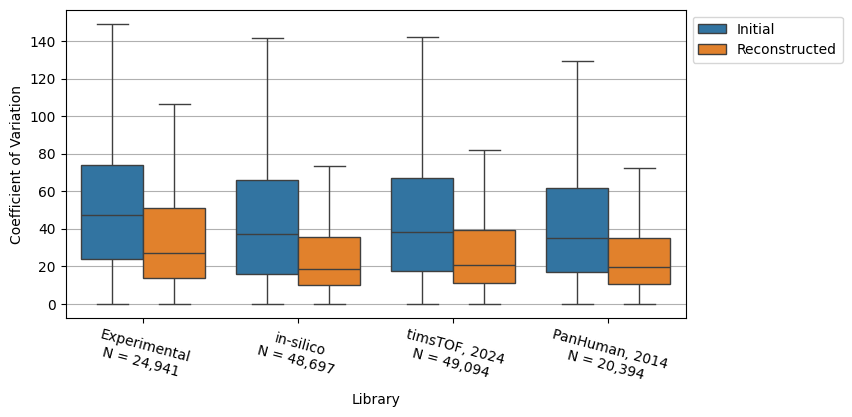

In [13]:
fig, ax = plt.subplots(1,1, figsize=(8, 4))
sns.boxplot(data=cvs_df, x='Library', hue='Condition', y='cv', showfliers=False, order=names.values(), ax=ax)
ax.set_xlabel("Library")
ax.set_ylabel("Coefficient of Variation")
tick_labels = [f'{i}\nN = {j:,}' for i, j in zip(names.values(), num_entries)]
ax.set_xticks(range(len(tick_labels)))
ax.set_xticklabels(tick_labels, rotation=-15)
ax.legend(bbox_to_anchor=(1,1))
plt.grid(axis='y')
plt.savefig("Figure-S6.png", dpi=300, bbox_inches='tight')